In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


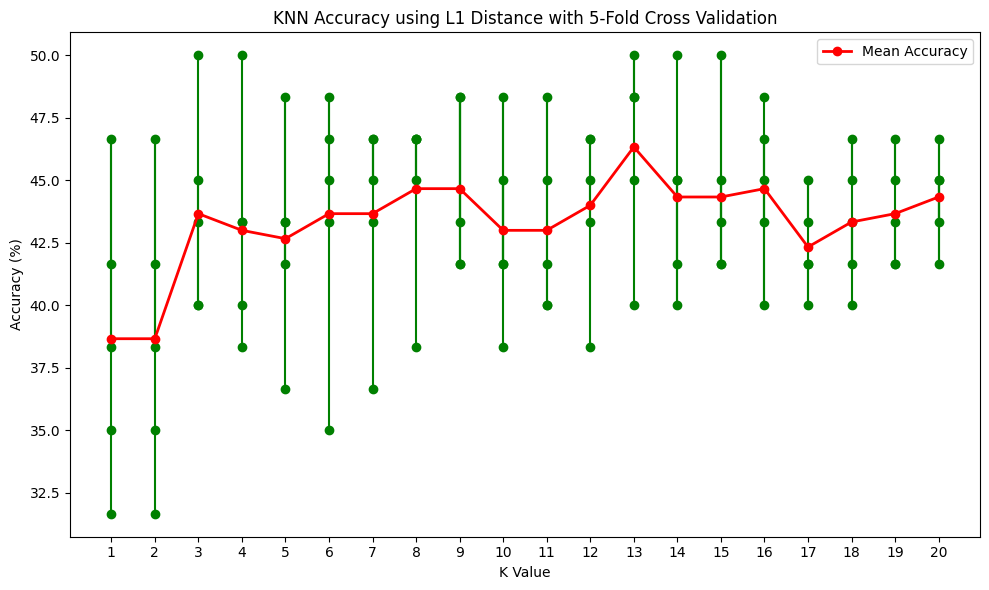

In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from collections import Counter

DATASET_PATH = "/content/drive/MyDrive/archive/archive/animals"
CLASSES = ['dogs', 'panda', 'cats']
IMAGES_PER_CLASS = 100
IMG_SIZE = (32, 32)
K_VALUES = range(1, 21)
N_SPLITS = 5

def load_images():
    data = []
    labels = []
    for idx, class_name in enumerate(CLASSES):
        folder = os.path.join(DATASET_PATH, class_name)
        files = sorted(os.listdir(folder))[:IMAGES_PER_CLASS]
        for file in files:
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            data.append(img.flatten())
            labels.append(idx)
    return np.array(data), np.array(labels)

def l1_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

def knn(X_train, y_train, test_sample, k):
    distances = [l1_distance(test_sample, train_sample) for train_sample in X_train]
    k_indices = np.argsort(distances)[:k]
    k_labels = [y_train[i] for i in k_indices]
    return Counter(k_labels).most_common(1)[0][0]

def knn_kfold(X, y, k_values, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    k_accuracies = {k: [] for k in k_values}

    for split_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for k in k_values:
            correct = 0
            for i in range(len(X_test)):
                pred = knn(X_train, y_train, X_test[i], k)
                if pred == y_test[i]:
                    correct += 1
            acc = (correct / len(X_test)) * 100
            k_accuracies[k].append(acc)
    return k_accuracies

X, y = load_images()
k_accuracies = knn_kfold(X, y, K_VALUES, N_SPLITS)

plt.figure(figsize=(10, 6))
for k in K_VALUES:
    plt.scatter([k] * len(k_accuracies[k]), k_accuracies[k], alpha=1.0, color='green')
    plt.plot([k] * len(k_accuracies[k]), k_accuracies[k], alpha=1.0, color='green')

mean_acc = [np.mean(k_accuracies[k]) for k in K_VALUES]
plt.plot(K_VALUES, mean_acc, color='red', marker='o', linewidth=2, label="Mean Accuracy")

plt.title("KNN Accuracy using L1 Distance with 5-Fold Cross Validation")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()
plt.show()
